# PDE Style Inpainting

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import cv2

import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
# ---------------------------------------------------
# Dataset paths
# ---------------------------------------------------

DATA_DIR = Path("../data/raw/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

train_paths = sorted(list(TRAIN_DIR.glob("*/*.jpg")))
val_paths = sorted(list(VAL_DIR.glob("*/*.jpg")))
test_paths = sorted(list(TEST_DIR.glob("*/*.jpg")))

print(f"Train images: {len(train_paths)}")
print(f"Val images:   {len(val_paths)}")
print(f"Test images:  {len(test_paths)}")

Train images: 18400
Val images:   2800
Test images:  2800


In [3]:
TARGET_SIZE = (256, 128)

def preprocess_image(path, target_size=TARGET_SIZE):
    img = Image.open(path).convert("L")
    img = img.resize(target_size, resample=Image.BILINEAR)
    arr = np.array(img).astype(np.float32) / 255.0
    return arr


def horizontal_stripe_mask(shape, stripe_height=24):
    h, w = shape
    mask = np.ones((h, w), dtype=np.float32)
    center = h // 2
    top = center - stripe_height // 2
    mask[top:top+stripe_height, :] = 0.0
    return mask

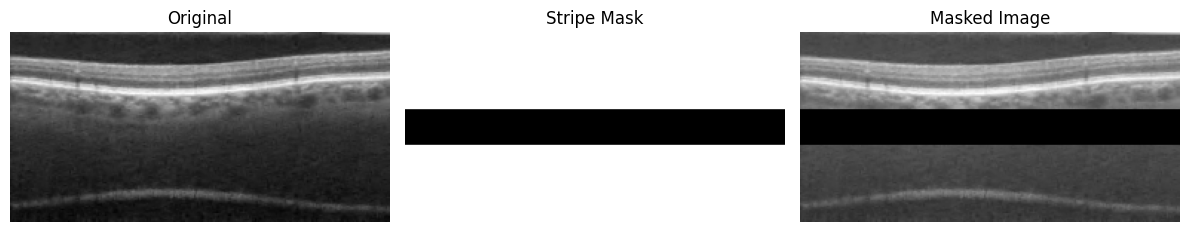

In [4]:
# ---------------------------------------------------
# Sample image + stripe corruption
# ---------------------------------------------------

sample_path = train_paths[0]

original = preprocess_image(sample_path)

mask = horizontal_stripe_mask(
    original.shape,
    stripe_height=24
)

masked = original * mask

fig, axes = plt.subplots(1, 3, figsize=(12,4))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Stripe Mask")
axes[1].axis("off")

axes[2].imshow(masked, cmap="gray")
axes[2].set_title("Masked Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# ---------------------------------------------------
# PDE diffusion reconstruction
# ---------------------------------------------------

def pde_diffusion_reconstruction(
    masked_image,
    mask,
    n_iters=500,
    dt=0.1
):
    """
    Heat-equation style diffusion reconstruction.
    
    Known pixels remain fixed.
    Missing pixels evolve according to diffusion.
    """
    
    u = masked_image.copy()
    
    known_pixels = mask == 1
    missing_pixels = mask == 0
    
    for _ in range(n_iters):
        
        # Discrete Laplacian
        laplacian = (
            np.roll(u, 1, axis=0) +
            np.roll(u, -1, axis=0) +
            np.roll(u, 1, axis=1) +
            np.roll(u, -1, axis=1) -
            4 * u
        )
        
        # Update only missing region
        u[missing_pixels] = (
            u[missing_pixels]
            +
            dt * laplacian[missing_pixels]
        )
        
        # Keep observed pixels fixed
        u[known_pixels] = masked_image[known_pixels]
    
    return u

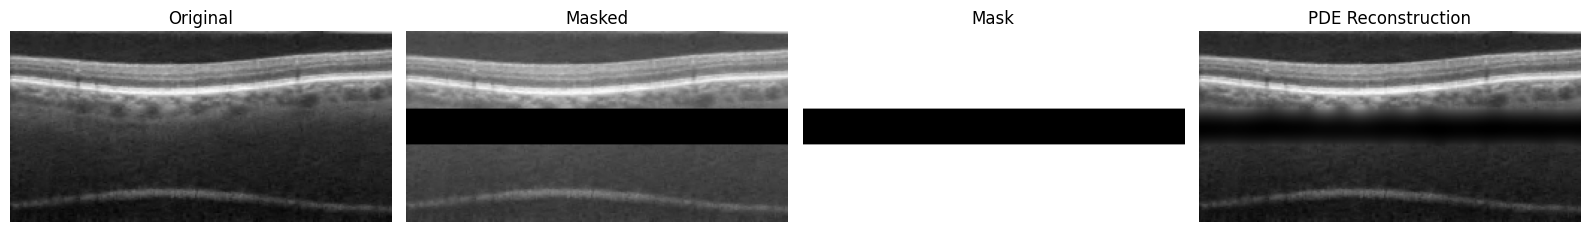

In [6]:
# ---------------------------------------------------
# Run PDE reconstruction
# ---------------------------------------------------

pde_recon = pde_diffusion_reconstruction(
    masked,
    mask,
    n_iters=500,
    dt=0.1
)

fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked, cmap="gray")
axes[1].set_title("Masked")
axes[1].axis("off")

axes[2].imshow(mask, cmap="gray")
axes[2].set_title("Mask")
axes[2].axis("off")

axes[3].imshow(pde_recon, cmap="gray")
axes[3].set_title("PDE Reconstruction")
axes[3].axis("off")

plt.tight_layout()
plt.show()